**Workflow:**
1. Load data and sort columns by missing values.
2. Fit AutoARIMA models to each column using exhaustive search.
3. Forecast future values and fill missing data points up to a specified date.
4. Perform walk-forward validation to evaluate model performance at different horizons (1-8 steps).
5. Report validation metrics (RMSE, MAE, MAPE, Directional Accuracy).
6. Visualize the forecast specifically for the 'House_Index'.
7. Save the completed dataset.

# 1. Import Libraries & Utility File

Our approach in this notebook will be to do some EDA and initial forecasts using the popular econometric model ARIMA. Luckily there's a very powerful tool for python named autoarima which does a ton of EDA for us. We can use this to test for stationarity, differencing, finding the optimal hyperparameters, and determining seasonal decomposition. Since ARIMA is a proven economic metric that works well with autocorrelated features, which is likely most if not all of the economic variables in our gathered dataset.

In [1]:
# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os # For checking file existence

# Import our custom utility module
try:
    import dc_housing_arima_utils as arima_utils
    print("Successfully imported dc_housing_arima_utils.")
except ImportError:
    print("Error: Could not import dc_housing_arima_utils.py.")
    print("Ensure the file is in the same directory or Python path.")
# Suppress warnings for cleaner notebook output
warnings.filterwarnings("ignore")

Successfully imported dc_housing_arima_utils.


# 2. Configuration

In [2]:
DATA_FILE_PATH = 'DC_Master_Missing.csv'
FORECAST_END_DATE = '2027-01-01' # Date to forecast until
N_TEST_QUARTERS = 36 # Number of quarters for walk-forward validation test set
STEPS_TO_CALCULATE = list(range(1, 9)) # Forecast horizons for metrics (1 to 8 steps)
STEPS_TO_PLOT = [1, 4, 8] # Specific forecast horizons to visualize

# 3. Load Data

In [3]:
# Check if data file exists
if not os.path.exists(DATA_FILE_PATH):
    raise FileNotFoundError(f"Error: Input data file not found at '{DATA_FILE_PATH}'")

# Load data using utility function (includes sorting columns by NaNs)
df, sorted_columns = arima_utils.load_data(DATA_FILE_PATH)

# Display basic info if loaded successfully
if df is not None:
    print("\nData loaded successfully.")
    print("DataFrame shape:", df.shape)
    print("Columns sorted by missing values:", sorted_columns)
    # print(df.head()) # Optional: display head
else:
    raise RuntimeError("Failed to load data. Please check file path and format.")

Loading data from: DC_Master_Missing.csv
  Inferred frequency: QS-OCT. Setting frequency.
Sorting columns by missing values (ascending):
  Sorted columns order: ['Unemployment_Rate', 'Interest_Rate', 'Mortgage_Rate', 'CPI', 'House_Index', 'GDP', 'Population', 'Poverty_Rate', 'Median_Household_Income']

Data loaded successfully.
DataFrame shape: (142, 9)
Columns sorted by missing values: ['Unemployment_Rate', 'Interest_Rate', 'Mortgage_Rate', 'CPI', 'House_Index', 'GDP', 'Population', 'Poverty_Rate', 'Median_Household_Income']


# 4. Summarize Optimal Models

Here we run autoarima on all the columns using a for loop. Before we do that, we use the Pandas sort function since our main df has missing values.We sort from least to most so we don't delete values for other variables that have less or no missing values before we run autoarima on it.

In [4]:
fitted_models = {} # Dictionary to store the fitted model for each column
print(f"\n--- Starting AutoARIMA Fitting Process for {len(sorted_columns)} Columns ---")

for col_name in sorted_columns:
    print(f"\nProcessing column: {col_name}")
    series = df[col_name]

    # Get data without NaNs for training
    train_data = series.dropna()

    if train_data.empty:
        print(f"  Skipping {col_name}: No non-NaN data available.")
        fitted_models[col_name] = None
        continue
    if len(train_data) < 8: # Need sufficient data points
         print(f"  Skipping {col_name}: Insufficient data points ({len(train_data)}).")
         fitted_models[col_name] = None
         continue

    try:
        # Call the utility function directly with desired parameters
        # Using exhaustive search as per original notebook
        model = arima_utils.fit_auto_arima(
            train_data,
            m=4,              # Quarterly data
            seasonal=True,
            stepwise=False,   # Exhaustive search
            max_p=8, max_q=8, # Non-seasonal order limits
            max_P=5, max_Q=5, # Seasonal order limits
            max_order=20,     # Total order limit
            trace=True,       # Show search progress
            error_action='ignore',
            suppress_warnings=True
        )

        print(f"  Successfully fitted ARIMA model for '{col_name}'.")
        print(f"  Optimal Order: {model.order}, Seasonal Order: {model.seasonal_order}")
        # Print the model summary
        print(model.summary())
        fitted_models[col_name] = model

    except Exception as e:
        print(f"  Error fitting model for {col_name}: {e}")
        fitted_models[col_name] = None # Store None if fitting failed

print("\n--- AutoARIMA Fitting Process Completed ---")
fitted_count = sum(1 for m in fitted_models.values() if m is not None)
print(f"Successfully fitted {fitted_count} models out of {len(sorted_columns)} columns processed.")



--- Starting AutoARIMA Fitting Process for 9 Columns ---

Processing column: Unemployment_Rate
  Fitting AutoARIMA (m=4, seasonal=True, stepwise=False)...
 ARIMA(0,0,0)(0,0,0)[4] intercept   : AIC=509.230, Time=0.04 sec
 ARIMA(0,0,0)(0,0,1)[4] intercept   : AIC=449.358, Time=0.06 sec
 ARIMA(0,0,0)(0,0,2)[4] intercept   : AIC=442.928, Time=0.09 sec
 ARIMA(0,0,0)(0,0,3)[4] intercept   : AIC=443.948, Time=0.13 sec
 ARIMA(0,0,0)(0,0,4)[4] intercept   : AIC=445.696, Time=0.34 sec
 ARIMA(0,0,0)(0,0,5)[4] intercept   : AIC=447.515, Time=0.31 sec
 ARIMA(0,0,0)(1,0,0)[4] intercept   : AIC=449.056, Time=0.11 sec
 ARIMA(0,0,0)(1,0,1)[4] intercept   : AIC=442.586, Time=0.19 sec
 ARIMA(0,0,0)(1,0,2)[4] intercept   : AIC=444.197, Time=0.45 sec
 ARIMA(0,0,0)(1,0,3)[4] intercept   : AIC=444.398, Time=0.46 sec
 ARIMA(0,0,0)(1,0,4)[4] intercept   : AIC=447.163, Time=0.45 sec
 ARIMA(0,0,0)(1,0,5)[4] intercept   : AIC=448.085, Time=0.63 sec
 ARIMA(0,0,0)(2,0,0)[4] intercept   : AIC=441.762, Time=0.13 sec

# 5. Summarize Optimal Models
So autoarima gave us a lot of preliminary insight on the data. We will eventually formally confirm many of the decisions ARIMA made for us, but for now let's make sure the fitted models are properly stored for us to run forecasts.

In [5]:
# Display the orders of the successfully fitted models.

print("\n--- Fitted Models Summary ---")
for col_name, model in fitted_models.items():
    if model:
        print(f"Column: {col_name}, Model Order: {model.order}, Seasonal Order: {model.seasonal_order}")
    else:
        print(f"Column: {col_name}, Model: Fitting Failed")


--- Fitted Models Summary ---
Column: Unemployment_Rate, Model Order: (2, 0, 1), Seasonal Order: (1, 0, 0, 4)
Column: Interest_Rate, Model Order: (2, 1, 2), Seasonal Order: (2, 0, 2, 4)
Column: Mortgage_Rate, Model Order: (0, 1, 0), Seasonal Order: (0, 0, 0, 4)
Column: CPI, Model Order: (1, 1, 0), Seasonal Order: (1, 0, 1, 4)
Column: House_Index, Model Order: (0, 1, 3), Seasonal Order: (1, 0, 0, 4)
Column: GDP, Model Order: (0, 2, 1), Seasonal Order: (0, 0, 0, 4)
Column: Population, Model Order: (2, 1, 1), Seasonal Order: (3, 0, 2, 4)
Column: Poverty_Rate, Model Order: (0, 1, 3), Seasonal Order: (5, 0, 2, 4)
Column: Median_Household_Income, Model Order: (3, 1, 1), Seasonal Order: (3, 0, 2, 4)


# 6. Forecast and Fill Missing Values 

Now to finish off, we decide to forecast until January 2027 just to give us some leg room on the models we might run next. This would also be useful for recursive forecasting using combined approaches. This is depending on what we find on subsequent models.

In [6]:
# Make a copy of the original DataFrame to fill
df_filled = df.copy()

# Define the final date for forecasting
forecast_end_date_ts = pd.to_datetime(FORECAST_END_DATE)
original_start_date = df.index.min() # Store original start date

# Reindex df_filled FIRST to ensure it has the full desired index range
print(f"\nReindexing DataFrame from {original_start_date.strftime('%Y-%m-%d')} to {forecast_end_date_ts.strftime('%Y-%m-%d')}...")
# Assuming quarterly start frequency ('QS' or 'QS-JAN') - adjust if needed
freq = pd.infer_freq(df.index) or 'QS'
print(f"Using frequency: {freq}")
full_index = pd.date_range(start=original_start_date, end=forecast_end_date_ts, freq=freq)
df_filled = df_filled.reindex(full_index)
print("Reindexing complete.")

print("\n--- Forecasting and Filling Missing Values ---")
for col_name, model in fitted_models.items():
    if model is None:
        print(f"\nSkipping forecast for {col_name}: Model fitting failed.")
        continue

    print(f"\nProcessing column: {col_name}")
    series_original = df[col_name].dropna() # Use original non-NaN data

    if series_original.empty:
        print(f"  Skipping forecast for {col_name}: No historical data.")
        continue

    last_valid_index = series_original.index.max()

    # Determine the date range for forecasting
    start_forecast_date = last_valid_index + pd.tseries.frequencies.to_offset(freq)

    if start_forecast_date > forecast_end_date_ts:
        print(f"  No forecast needed: Last valid data ({last_valid_index.strftime('%Y-%m-%d')}) >= forecast end date.")
        continue

    forecast_index = pd.date_range(start=start_forecast_date, end=forecast_end_date_ts, freq=freq)
    n_periods_to_forecast = len(forecast_index)

    if n_periods_to_forecast <= 0:
         print(f"  No forecast periods needed within the specified range.")
         continue

    print(f"  Last valid data at: {last_valid_index.strftime('%Y-%m-%d')}")
    print(f"  Forecasting {n_periods_to_forecast} steps from {start_forecast_date.strftime('%Y-%m-%d')} to {forecast_end_date_ts.strftime('%Y-%m-%d')}")

    try:
        # Generate point forecasts using the fitted model
        forecast_values = model.predict(n_periods=n_periods_to_forecast)

        # Ensure forecast_values is a pandas Series with the correct index
        if isinstance(forecast_values, np.ndarray):
             forecast_values = pd.Series(forecast_values, index=forecast_index)
        elif isinstance(forecast_values, pd.Series):
             forecast_values.index = forecast_index # Align index

        # Fill the values in the reindexed DataFrame using .loc
        df_filled.loc[forecast_index, col_name] = forecast_values
        print(f"  Filled {len(forecast_index)} values for {col_name}")

    except Exception as e:
        print(f"  Error during forecasting for {col_name}: {e}")


print("\n--- Forecasting and Filling Process Completed ---")

# Display the tail of the filled DataFrame and check for remaining NaNs
print("\nTail of the filled DataFrame:")
print(df_filled.tail(10))

print(f"\nRemaining NaNs check (up to {FORECAST_END_DATE}):")
print(df_filled.loc[:forecast_end_date_ts].isnull().sum())


Reindexing DataFrame from 1990-01-01 to 2027-01-01...
Using frequency: QS-OCT
Reindexing complete.

--- Forecasting and Filling Missing Values ---

Processing column: Unemployment_Rate
  Last valid data at: 2025-04-01
  Forecasting 7 steps from 2025-07-01 to 2027-01-01
  Filled 7 values for Unemployment_Rate

Processing column: Interest_Rate
  Last valid data at: 2025-04-01
  Forecasting 7 steps from 2025-07-01 to 2027-01-01
  Filled 7 values for Interest_Rate

Processing column: Mortgage_Rate
  Last valid data at: 2025-04-01
  Forecasting 7 steps from 2025-07-01 to 2027-01-01
  Filled 7 values for Mortgage_Rate

Processing column: CPI
  Last valid data at: 2025-01-01
  Forecasting 8 steps from 2025-04-01 to 2027-01-01
  Filled 8 values for CPI

Processing column: House_Index
  Last valid data at: 2024-10-01
  Forecasting 9 steps from 2025-01-01 to 2027-01-01
  Filled 9 values for House_Index

Processing column: GDP
  Last valid data at: 2024-10-01
  Forecasting 9 steps from 2025-01-0

# 7. Perform Walk-Forward Validation
Evaluate the performance of the fitted models using walk-forward validation. This involves iteratively refitting the model on expanding windows of data and generating forecasts for multiple steps ahead on the held-out test set.


--- Starting Walk-Forward Validation for All Columns ---

--- Processing Column for Validation: Unemployment_Rate ---
  Validation Train Period: 1990-01-01 to 2016-04-01
  Validation Test Period : 2016-07-01 to 2025-04-01
  Starting walk-forward loop for 36 test points...
  Walk-forward loop finished.
  Calculating validation metrics...


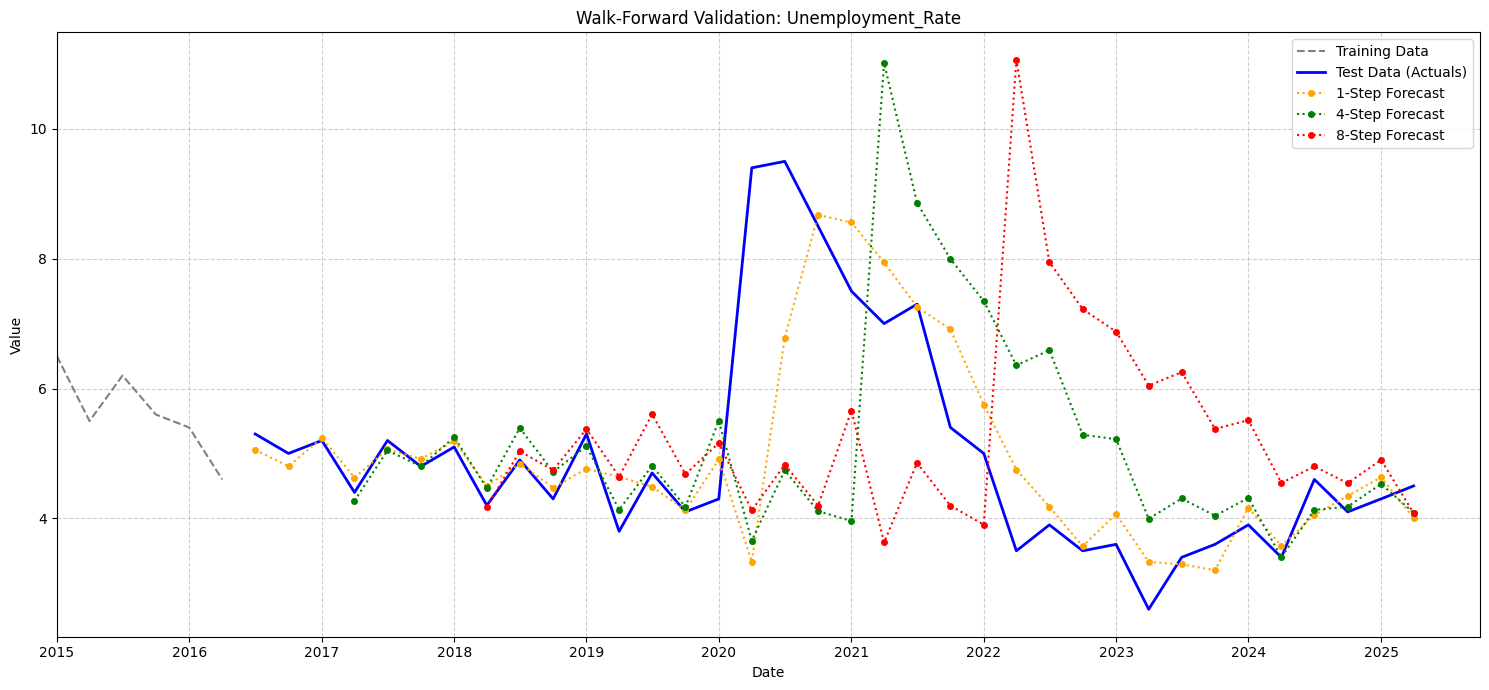


--- Processing Column for Validation: Interest_Rate ---
  Validation Train Period: 1990-01-01 to 2016-04-01
  Validation Test Period : 2016-07-01 to 2025-04-01
  Starting walk-forward loop for 36 test points...
  Walk-forward loop finished.
  Calculating validation metrics...


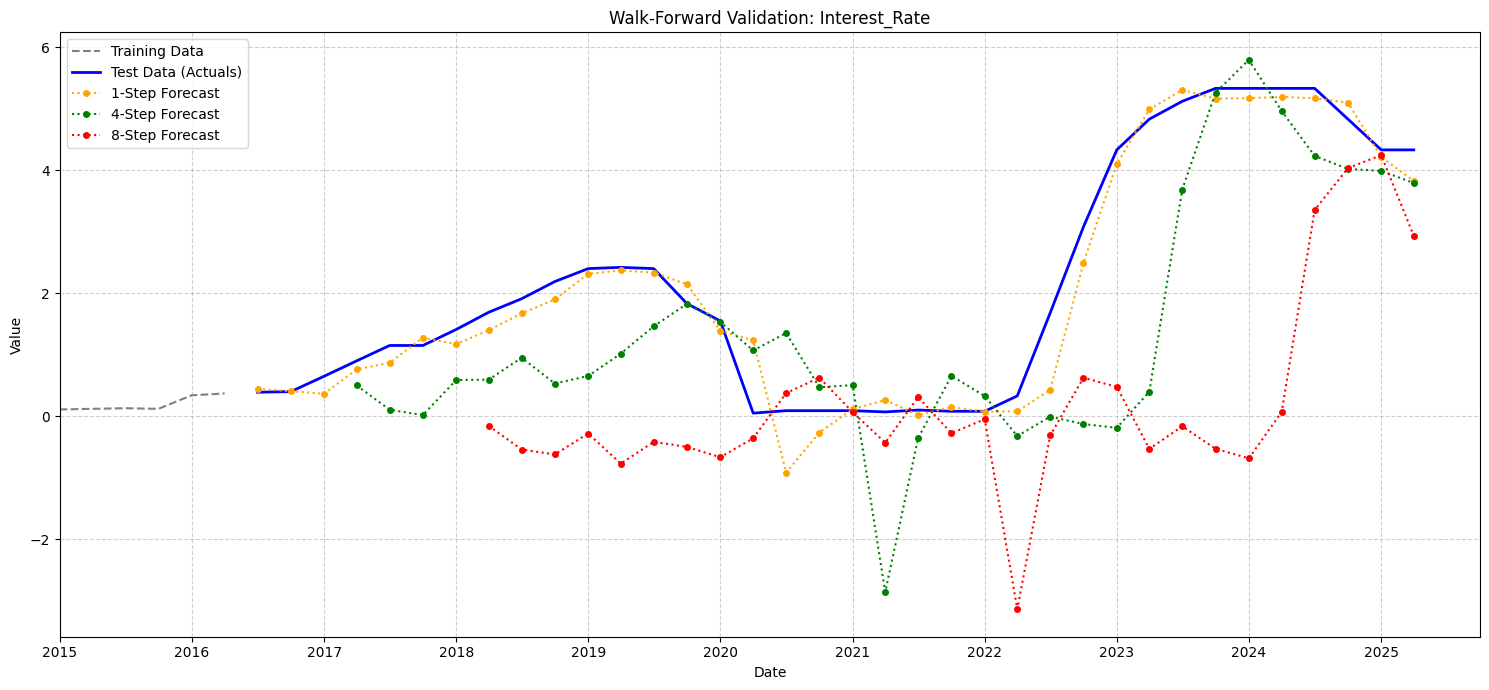


--- Processing Column for Validation: Mortgage_Rate ---
  Validation Train Period: 1990-01-01 to 2016-04-01
  Validation Test Period : 2016-07-01 to 2025-04-01
  Starting walk-forward loop for 36 test points...
  Walk-forward loop finished.
  Calculating validation metrics...


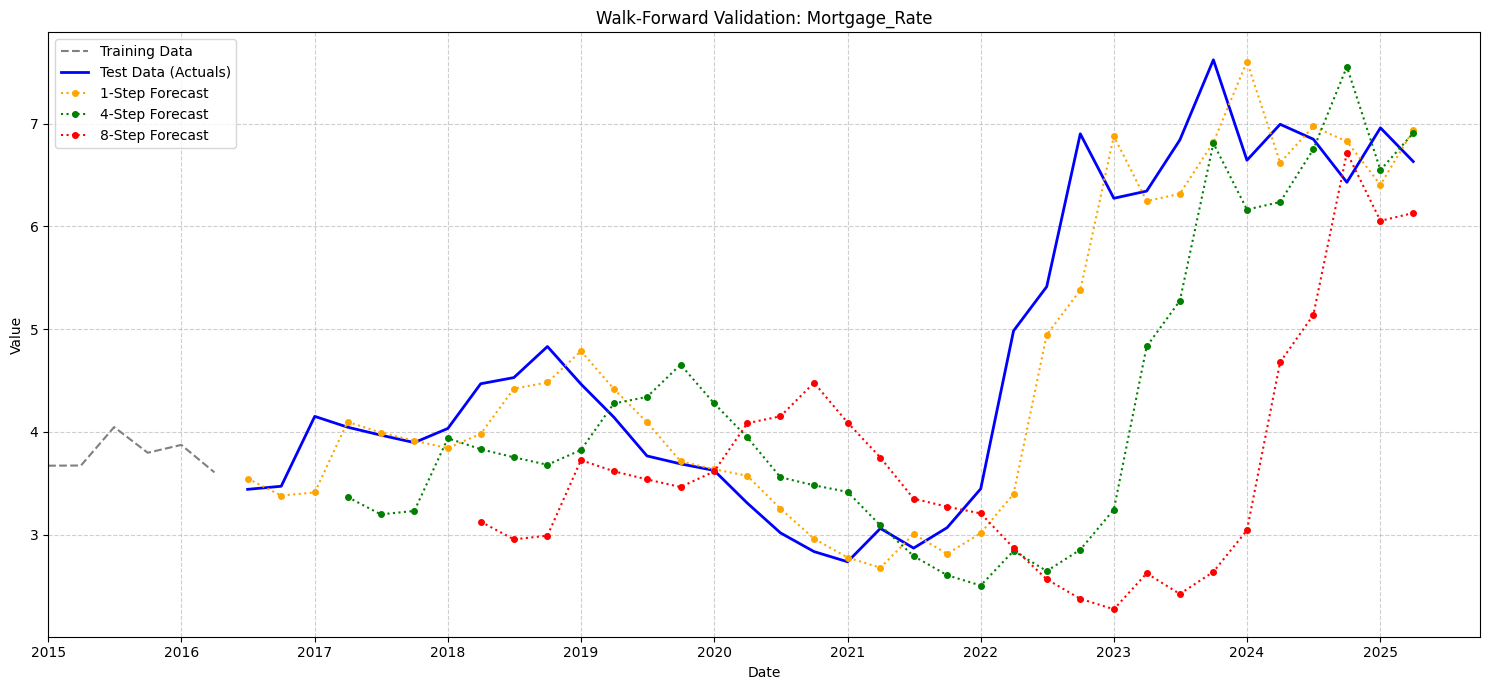


--- Processing Column for Validation: CPI ---
  Validation Train Period: 1990-01-01 to 2016-01-01
  Validation Test Period : 2016-04-01 to 2025-01-01
  Starting walk-forward loop for 36 test points...
  Walk-forward loop finished.
  Calculating validation metrics...


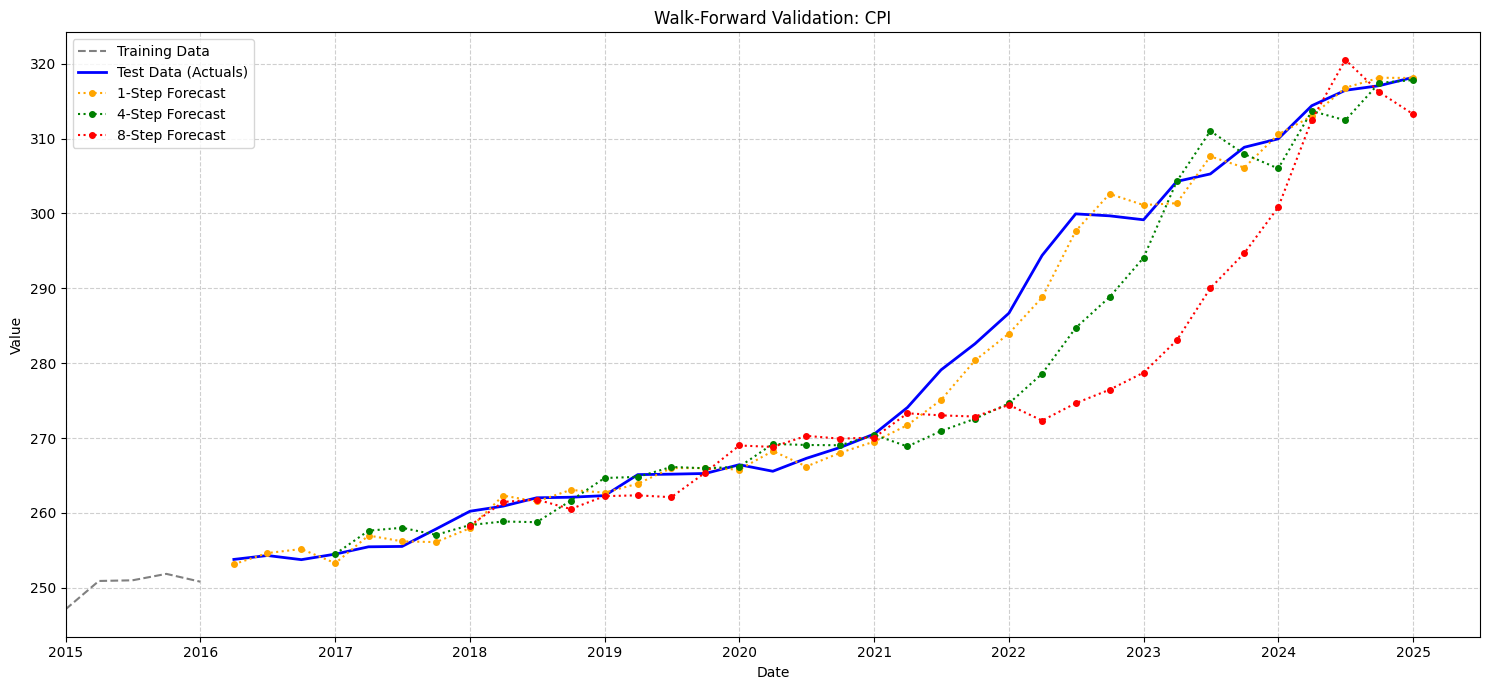


--- Processing Column for Validation: House_Index ---
  Validation Train Period: 1990-01-01 to 2015-10-01
  Validation Test Period : 2016-01-01 to 2024-10-01
  Starting walk-forward loop for 36 test points...
  Walk-forward loop finished.
  Calculating validation metrics...


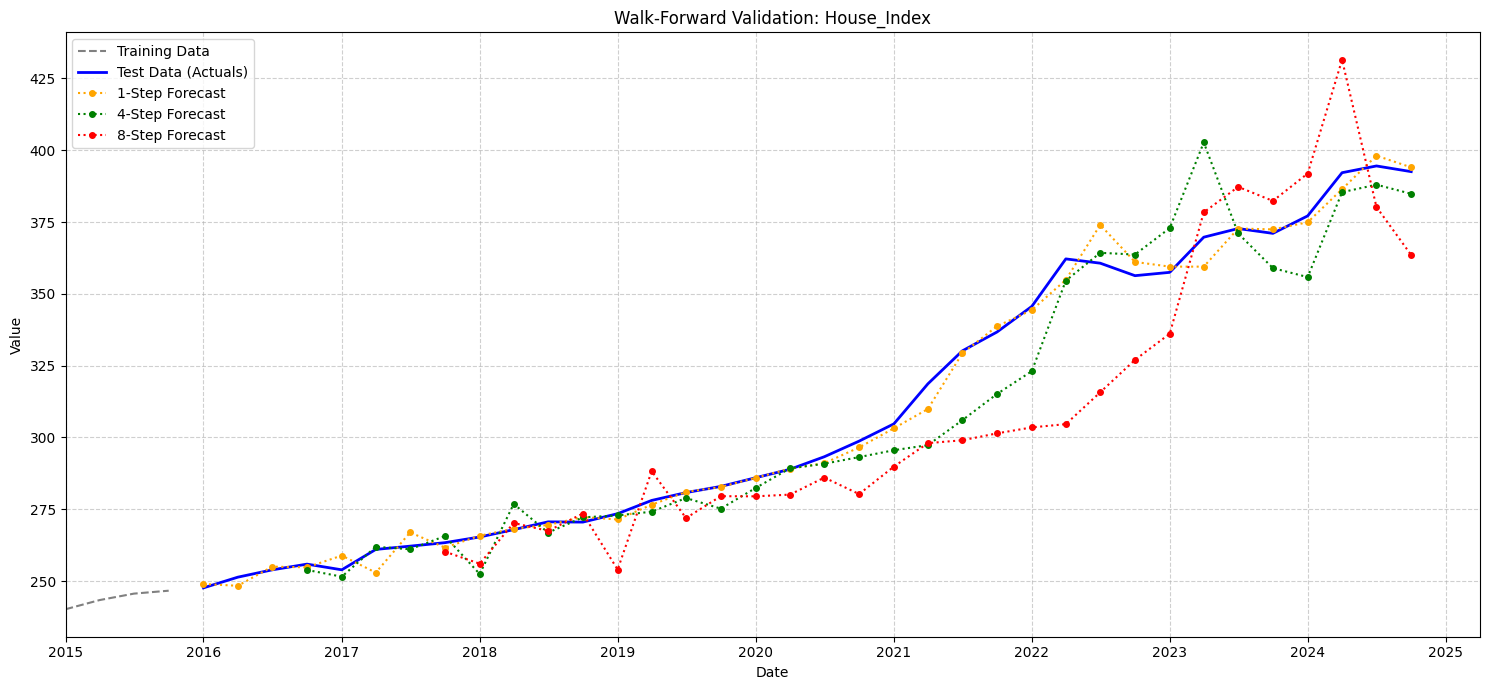


--- Processing Column for Validation: GDP ---
  Validation Train Period: 1990-01-01 to 2015-10-01
  Validation Test Period : 2016-01-01 to 2024-10-01
  Starting walk-forward loop for 36 test points...
  Walk-forward loop finished.
  Calculating validation metrics...


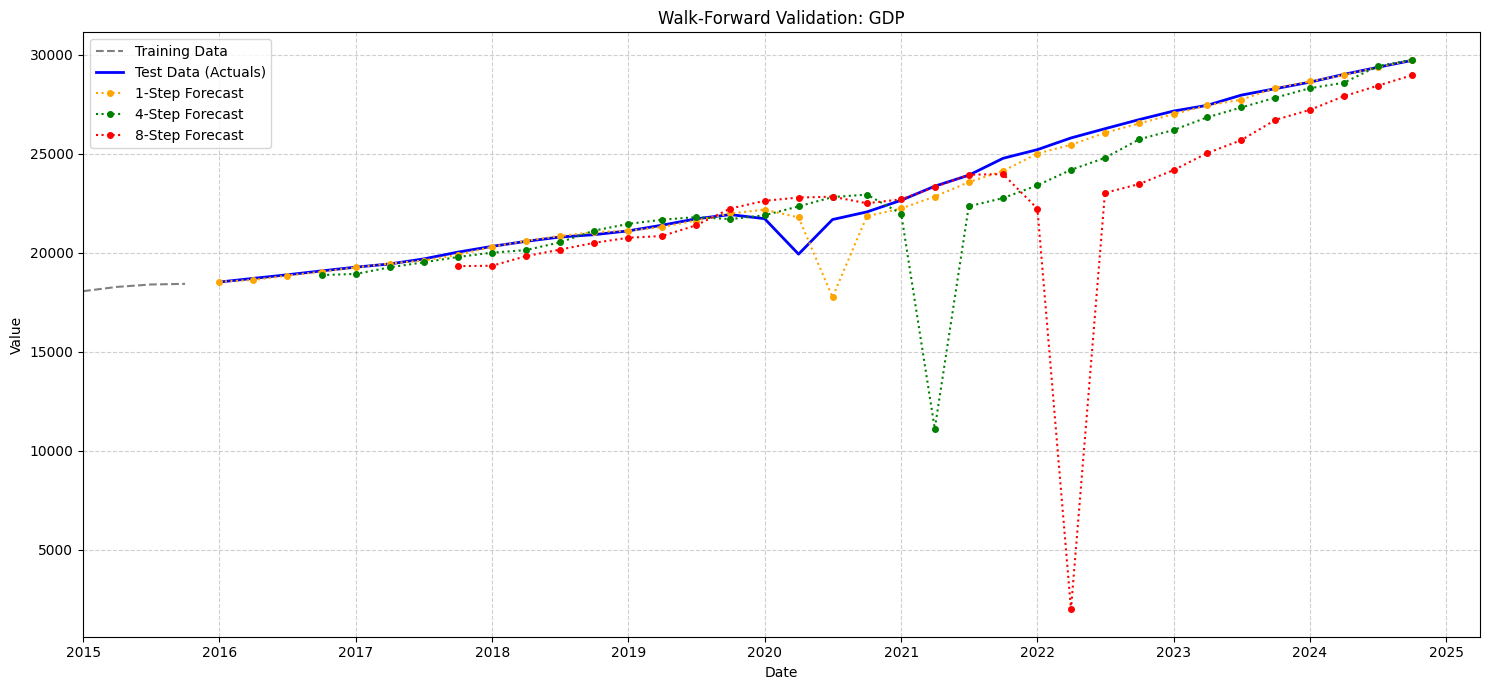


--- Processing Column for Validation: Population ---
  Validation Train Period: 1990-01-01 to 2015-07-01
  Validation Test Period : 2015-10-01 to 2024-07-01
  Starting walk-forward loop for 36 test points...
  Walk-forward loop finished.
  Calculating validation metrics...


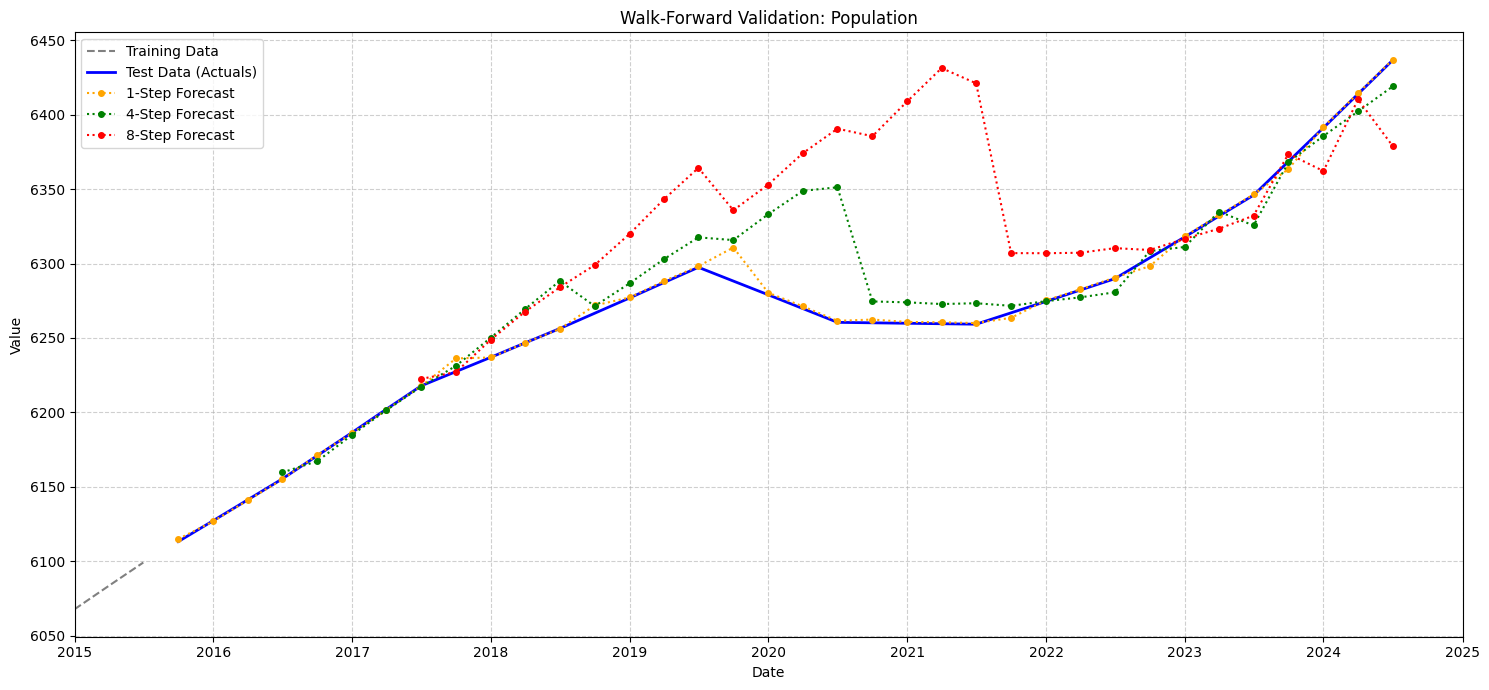


--- Processing Column for Validation: Poverty_Rate ---
  Validation Train Period: 1990-01-01 to 2014-01-01
  Validation Test Period : 2014-04-01 to 2023-01-01
  Starting walk-forward loop for 36 test points...
  Walk-forward loop finished.
  Calculating validation metrics...


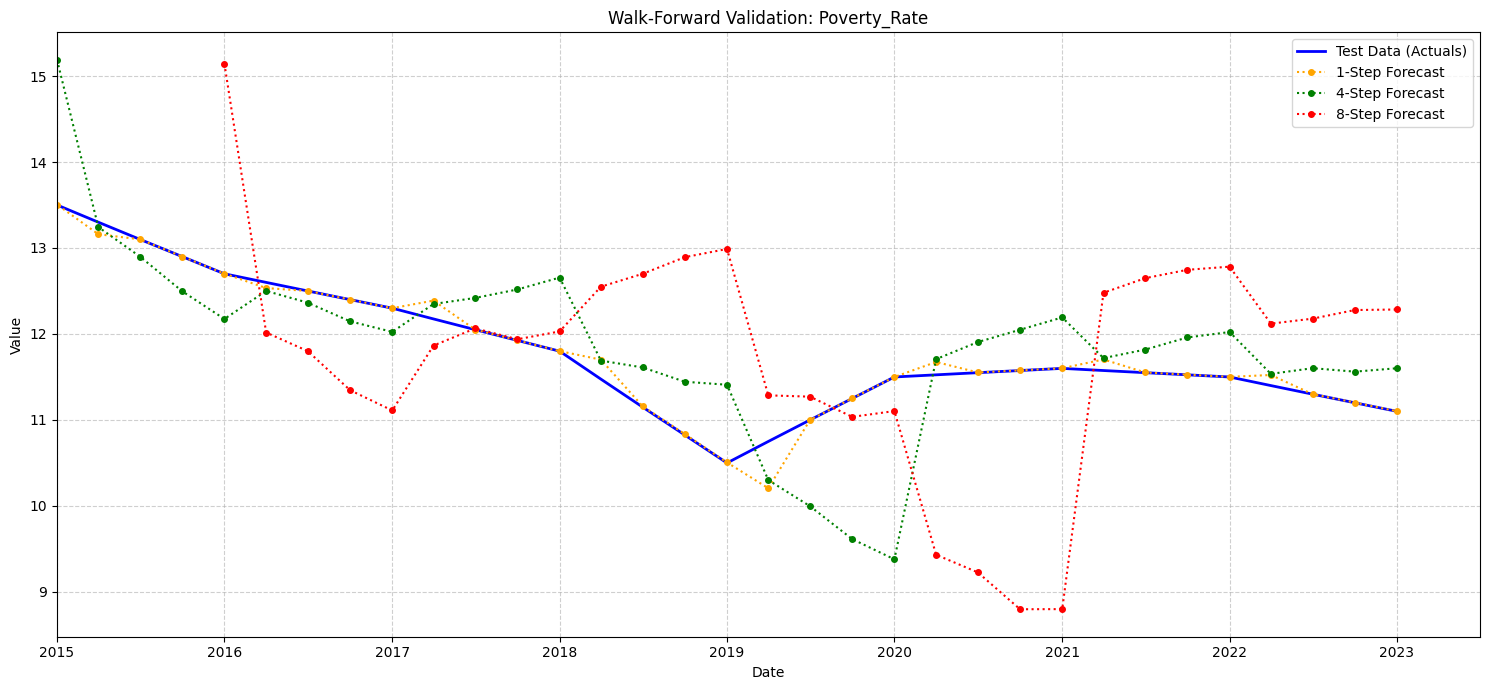


--- Processing Column for Validation: Median_Household_Income ---
  Validation Train Period: 1990-01-01 to 2014-01-01
  Validation Test Period : 2014-04-01 to 2023-01-01
  Starting walk-forward loop for 36 test points...
  Walk-forward loop finished.
  Calculating validation metrics...


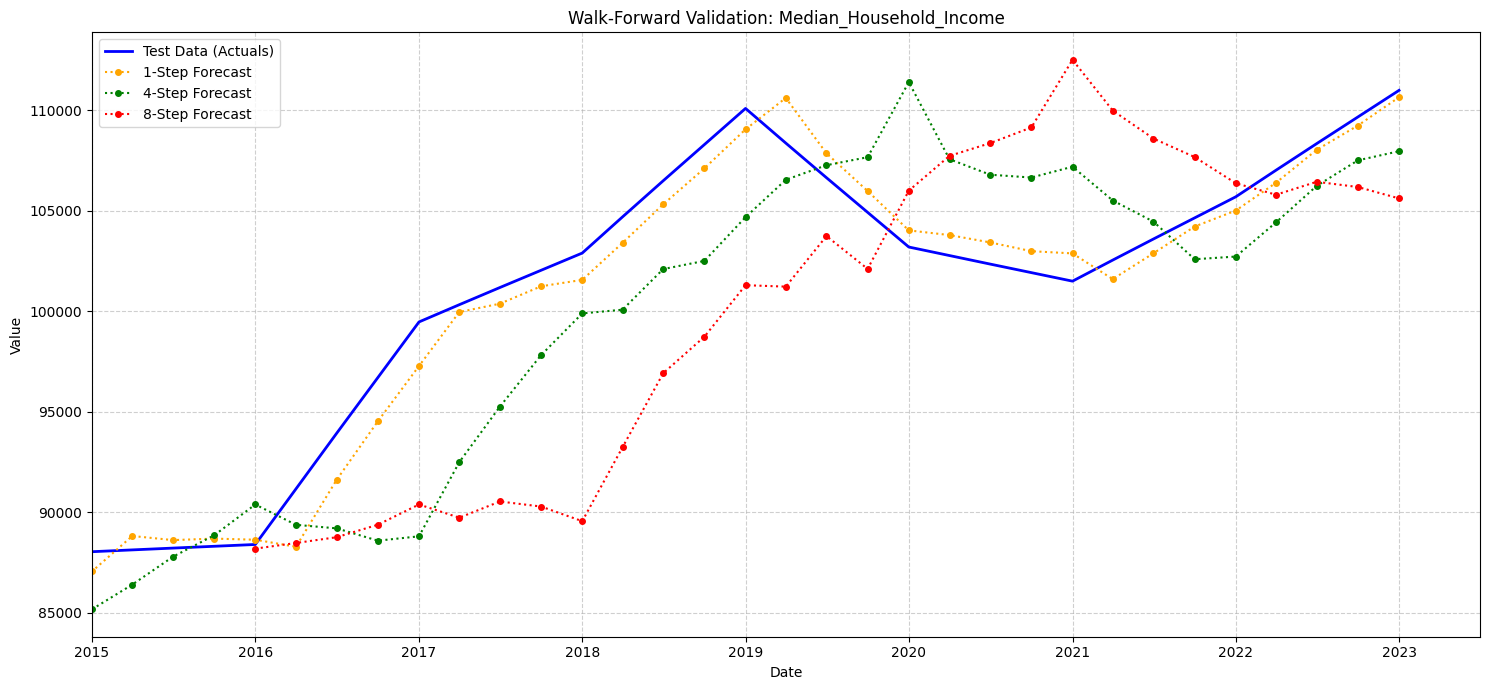


--- Walk-Forward Validation Completed for All Applicable Columns ---


In [7]:
print("\n--- Starting Walk-Forward Validation for All Columns ---")

all_column_metrics = {}
all_column_predictions = {} # Stores detailed predictions/actuals if needed

for col_name, model_template in fitted_models.items():
    if model_template is None:
        print(f"\n--- Skipping Validation for Column: {col_name} (No valid model) ---")
        continue

    print(f"\n--- Processing Column for Validation: {col_name} ---")

    # Prepare data: Use original series, drop NaNs, ensure float type
    series = df[col_name].dropna().astype(float)

    if len(series) < N_TEST_QUARTERS + 10: # Check if enough data for validation split
         print(f"  Skipping validation for {col_name}: Insufficient data ({len(series)}) for {N_TEST_QUARTERS} test quarters.")
         continue

    # Perform walk-forward validation using the utility function
    # This function handles the loop, refitting, prediction, and returns raw results
    predictions, actuals, history, prediction_indices = arima_utils.perform_walk_forward_validation(
        series=series,
        order=model_template.order,
        seasonal_order=model_template.seasonal_order,
        n_test_quarters=N_TEST_QUARTERS,
        steps_to_calculate=STEPS_TO_CALCULATE
    )

    # Store detailed results (optional, useful for deeper analysis)
    all_column_predictions[col_name] = {
        'preds': predictions,
        'actuals': actuals,
        'history': history,
        'indices': prediction_indices
    }

    # Calculate metrics based on the validation results
    metrics_summary = arima_utils.calculate_validation_metrics(
        predictions=predictions,
        actuals=actuals,
        history=history,
        steps_to_calculate=STEPS_TO_CALCULATE
    )
    all_column_metrics[col_name] = metrics_summary

    # Visualize the walk-forward results for this column
    # Get train/test split again just for plotting context
    train_data_initial = series[:-N_TEST_QUARTERS]
    test_data = series[-N_TEST_QUARTERS:]
    arima_utils.plot_walk_forward_results(
        column_name=col_name,
        train_data=train_data_initial,
        test_data=test_data,
        predictions=predictions,
        prediction_indices=prediction_indices,
        steps_to_plot=STEPS_TO_PLOT
        # viz_start_date can be customized here if needed
    )

print("\n--- Walk-Forward Validation Completed for All Applicable Columns ---")

# 8. Report Overall Metrics

Consolidate and display the calculated metrics from the walk-forward validation across all columns and forecast steps (1-8).

In [8]:
print("\n--- Walk-Forward Validation Metrics Summary (Steps 1-8) ---")
# Use the utility function to create and format the metrics DataFrame
metrics_df = arima_utils.create_metrics_df(all_column_metrics)

# Print the formatted DataFrame using to_string for better alignment
if not metrics_df.empty:
    print(metrics_df.to_string(float_format="%.3f"))
else:
    print("No metrics were generated.")


--- Walk-Forward Validation Metrics Summary (Steps 1-8) ---
                                     RMSE      MAE    MAPE          MSE  Directional Accuracy  Count
Column                  Step_Num                                                                    
CPI                     1           1.969    1.599   0.569        3.878                86.111     36
                        2           3.301    2.257   0.798       10.896                94.286     35
                        3           4.528    3.081   1.078       20.507               100.000     34
                        4           5.732    3.696   1.288       32.854               100.000     33
                        5           7.122    4.602   1.591       50.723               100.000     32
                        6           8.399    5.553   1.903       70.548               100.000     31
                        7           9.623    6.281   2.139       92.607               100.000     30
                        8     

# 9. Visualize Forecast for House Price Index
Generate and display a specific forecast plot for the 'House_Index', showing the predicted trend and 95% confidence intervals.


--- Generating Final Forecast Plot for: House_Index ---
  Generating 8-step ahead forecast from 2024-10-01...
  Inferred/Assumed frequency for forecast index: QS-OCT


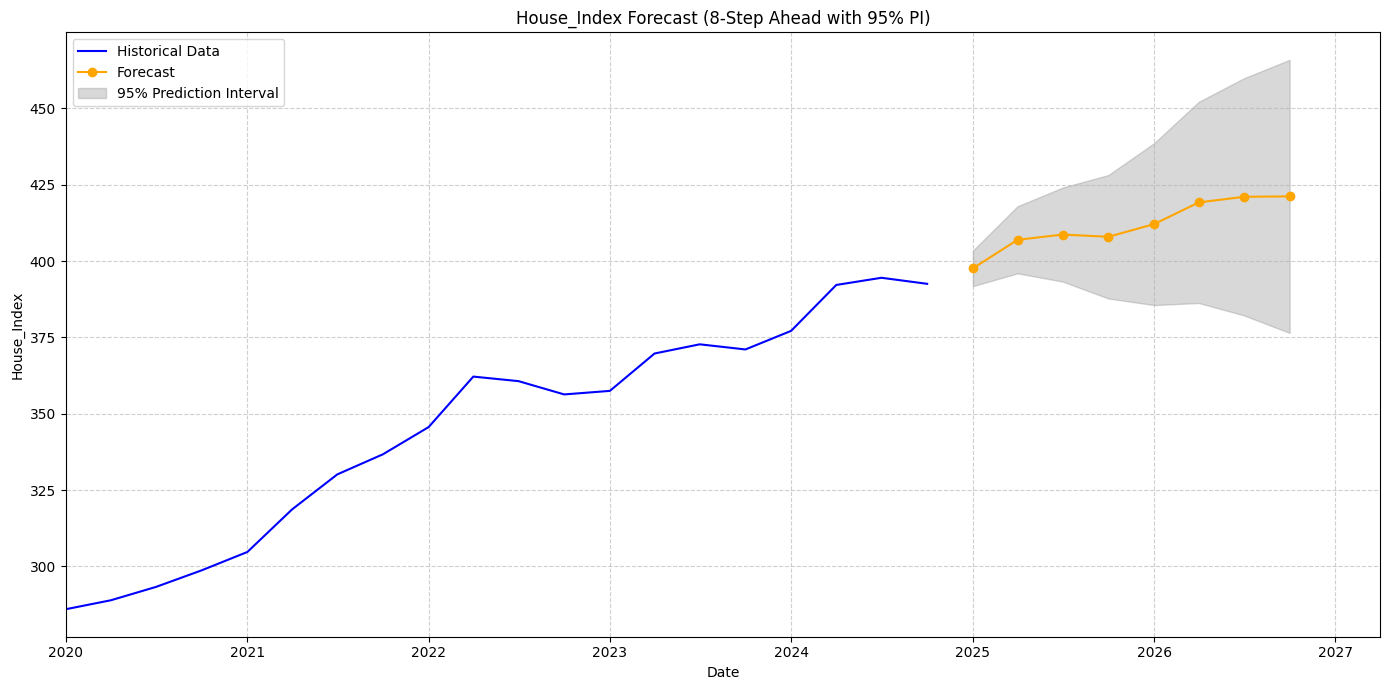


--- Forecasts for House_Index ---
              Forecast  Lower 95% CI  Upper 95% CI
2025-01-01  397.595329    391.774654    403.416005
2025-04-01  406.950854    395.965340    417.936369
2025-07-01  408.671504    393.274223    424.068784
2025-10-01  407.948236    387.724248    428.172224
2026-01-01  412.088262    385.580686    438.595839
2026-04-01  419.200875    386.262157    452.139593
2026-07-01  421.035746    382.201595    459.869896
2026-10-01  421.181215    376.461116    465.901315


In [9]:
col_name_to_plot = 'House_Index'
print(f"\n--- Generating Final Forecast Plot for: {col_name_to_plot} ---")

if col_name_to_plot not in fitted_models or fitted_models[col_name_to_plot] is None:
    print(f"Cannot generate plot: Model for {col_name_to_plot} not found or failed to fit.")
else:
    # Get the original series data (non-filled)
    house_index_series = df[col_name_to_plot].dropna().astype(float)
    # Get the final fitted model for this series
    model_to_forecast = fitted_models[col_name_to_plot]

    # Use the utility plotting function
    forecast_df = arima_utils.plot_forecast(
        series=house_index_series,
        model=model_to_forecast,
        forecast_steps=8, # Forecast 8 steps ahead
        start_date='2020-01-01', # Start plot from 2020
        title=f'{col_name_to_plot} Forecast (8-Step Ahead with 95% PI)'
    )
    if forecast_df is not None:
        print(f"\n--- Forecasts for {col_name_to_plot} ---")
        print(forecast_df)

# 10. Summary & Save Results

The auto_arima function successfully identified and fitted appropriate SARIMA models for the diverse set of quarterly DC economic indicators, capturing various levels of trend and seasonality across the time series. These baseline models proved useful not only for understanding the historical patterns but also for practical applications like forecasting to fill missing data points, creating a complete dataset extending to early 2027. 

The rigorous walk-forward validation provided valuable insights into the models' predictive performance at different horizons. As expected, forecast accuracy generally decreased for longer forecast steps (1-step vs. 8-step), evidenced by increasing RMSE and MAE values for most indicators. Directional accuracy also tended to decline over longer horizons, highlighting the increasing challenge of predicting market turns further out. Some indicators, like Mortgage Rate (with a simpler ARIMA(0,1,0) model), appeared relatively easier to forecast in the short term compared to more complex series like GDP (ARIMA(0,2,1)). 

The specific forecast for the House Price Index projected a continued, albeit potentially slowing, upward trend over the next two years, though the widening prediction interval underscored the inherent uncertainty in longer-range housing market predictions. Overall, this SARIMA analysis establishes a quantitative baseline for forecasting these DC economic indicators and understanding the associated forecast reliability.

Next, we will formally confirm some of autoarima's findings, then do feature engineering.

In [10]:
# --- Save Final Filled DataFrame ---
OUTPUT_CSV_PATH = 'DC_Master_ARIMA_Filled_Notebook.csv'
try:
    # Reset index to make 'Date' a column for the CSV
    df_filled_to_save = df_filled.reset_index()
    # Rename the index column if it's named 'index' after reset
    if 'index' in df_filled_to_save.columns:
         df_filled_to_save = df_filled_to_save.rename(columns={'index': 'Date'})

    df_filled_to_save.to_csv(OUTPUT_CSV_PATH, index=False)
    print(f"\nFilled dataset successfully saved to: {OUTPUT_CSV_PATH}")
except Exception as e:
    print(f"\nError saving filled dataset to {OUTPUT_CSV_PATH}: {e}")

print("\n--- Analysis Complete ---")


Filled dataset successfully saved to: DC_Master_ARIMA_Filled_Notebook.csv

--- Analysis Complete ---
